# SARIMA Time Series Forecasting: Boston Crime Incident Volume
# DS 4420 Final Project
# SioWa Luo, Li Zou, Shijie Lin

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm as sp_norm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product

warnings.filterwarnings("ignore")

## Load Data and Monthly Aggregation

In [2]:
def load_and_aggregate_monthly(filepath):
    """
    Load combined crime CSV and aggregate to monthly counts.

    Returns DataFrame indexed by month-start date with 'MS' frequency.
    """
    df = pd.read_csv(filepath, low_memory=False)
    # dates have mixed timezone formats (2015-2018 naive, 2019+ UTC)
    df["OCCURRED_ON_DATE"] = pd.to_datetime(df["OCCURRED_ON_DATE"], format = "mixed", utc = True)

    # count incidents per year and month
    monthly = df.groupby(["YEAR", "MONTH"]).size().reset_index(name = "crime_count")
    monthly["date"] = pd.to_datetime(monthly[["YEAR", "MONTH"]].assign(DAY = 1))
    monthly = monthly.sort_values("date").reset_index(drop = True)

    # drop partial months (month that get cut off)
    partial = (
        ((monthly.YEAR == 2015) & (monthly.MONTH == 6)) |
        ((monthly.YEAR == 2026) & (monthly.MONTH == 2))
    )

    monthly = monthly[~partial].reset_index(drop = True)

    # set date index with monthly frequency for statsmodel
    monthly = monthly.set_index("date")
    monthly.index = pd.DatetimeIndex(monthly.index).to_period("M").to_timestamp()
    monthly.index.freq = "MS"

    return monthly[["crime_count"]]

In [3]:
# Load data and display brief data info
monthly = load_and_aggregate_monthly("boston_crime_combined.csv")

print(f"Monthly series: {len(monthly)} observations")
print(f"  Range: {monthly.index[0].strftime('%Y-%m')} to {monthly.index[-1].strftime('%Y-%m')}")
print(f"  Mean: {monthly.crime_count.mean():.0f}  Std: {monthly.crime_count.std():.0f}")

Monthly series: 127 observations
  Range: 2015-07 to 2026-01
  Mean: 7020  Std: 1100


## Train / Test Split

In [4]:
# Perform train test split
# hold out last 12 months for evaluation
n_test = 12

train = monthly.iloc[:-n_test]
test = monthly.iloc[-n_test:]

print(f"Train: {len(train)} months ({train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')})")
print(f"Test:  {len(test)} months ({test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')})")

Train: 115 months (2015-07 to 2025-01)
Test:  12 months (2025-02 to 2026-01)


## Model Brief Analysis

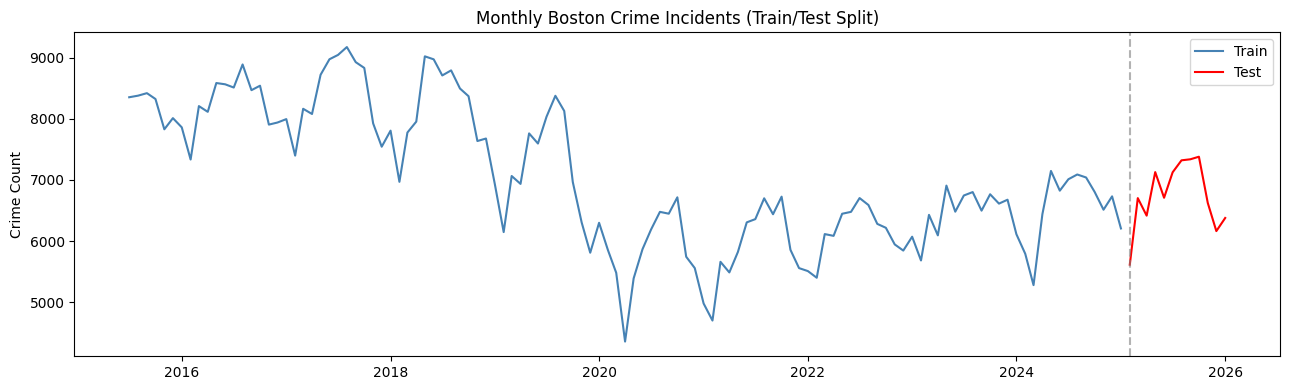

In [5]:
# plot raw series with train/test split
fig, ax = plt.subplots(figsize = (13, 4))

ax.plot(train.index, train.crime_count, color = "steelblue", label = "Train")
ax.plot(test.index, test.crime_count, color = "red", label = "Test")
ax.axvline(test.index[0], color = "gray", linestyle = "--", alpha = 0.6)

# Set format, titles, and labels
ax.set_title("Monthly Boston Crime Incidents (Train/Test Split)")
ax.set_ylabel("Crime Count")
ax.legend()
plt.tight_layout()
plt.show()

### Stationarity Testing (ADF Test) to determine differencing orders d and D by testing which transformations make the series stationary.


In [6]:
def run_adf_test(series, label):
    """Run Augmented Dickey-Fuller test.
    H0: unit root exists (non-stationary)
    H1: series is stationary
    """
    result = adfuller(series.dropna(), autolag="AIC")

    print(f"ADF Test - {label}:")
    print(f"  Statistic: {result[0]:.4f}  p-value: {result[1]:.4f}  Lags: {result[2]}")
    print(f"  Stationary at 5%: {result[1] < 0.05}")

    return result[1] < 0.05

In [7]:
# Display results
# Raw series (expected: non-stationary)
run_adf_test(train["crime_count"], "Raw monthly series")
print()

# First difference d=1 (removes trend)
run_adf_test(train["crime_count"].diff().dropna(), "First differenced (d=1)")
print()

# Seasonal difference D=1 s=12 (removes yearly seasonality)
run_adf_test(train["crime_count"].diff(12).dropna(), "Seasonally differenced (D=1, s=12)")
print()

# Both d=1 and D=1 (fully differenced working series)
diff_both = train["crime_count"].diff(12).diff().dropna()
run_adf_test(diff_both, "Double differenced (d=1, D=1)")

ADF Test - Raw monthly series:
  Statistic: -1.2083  p-value: 0.6700  Lags: 12
  Stationary at 5%: False

ADF Test - First differenced (d=1):
  Statistic: -2.3859  p-value: 0.1457  Lags: 13
  Stationary at 5%: False

ADF Test - Seasonally differenced (D=1, s=12):
  Statistic: -1.5527  p-value: 0.5073  Lags: 12
  Stationary at 5%: False

ADF Test - Double differenced (d=1, D=1):
  Statistic: -3.4238  p-value: 0.0102  Lags: 11
  Stationary at 5%: True


True

### ACF / PACF Analysis: Use the d=1, D=1 differenced series to identify non-seasonal (p, q) and seasonal (P, Q) parameters.

In [8]:
print(len(diff_both.dropna()))
print(diff_both.dropna())

102
date
2016-08-01    352.0
2016-09-01   -462.0
2016-10-01    169.0
2016-11-01   -141.0
2016-12-01   -149.0
              ...  
2024-09-01    255.0
2024-10-01   -505.0
2024-11-01   -138.0
2024-12-01    155.0
2025-01-01     39.0
Freq: MS, Name: crime_count, Length: 102, dtype: float64


In [9]:
print(monthly.head())
print(monthly.tail())
print(len(monthly))

            crime_count
date                   
2015-07-01         8355
2015-08-01         8381
2015-09-01         8422
2015-10-01         8326
2015-11-01         7830
            crime_count
date                   
2025-09-01         7339
2025-10-01         7381
2025-11-01         6624
2025-12-01         6163
2026-01-01         6378
127


In [10]:
# Get ACF and PACF on the fully differenced series
acf_vals = acf(diff_both.dropna(), nlags=36)
pacf_vals = pacf(diff_both.dropna(), nlags=36, method="ywm")
ci = 1.96 / np.sqrt(len(diff_both.dropna()))  # 95% confidence band

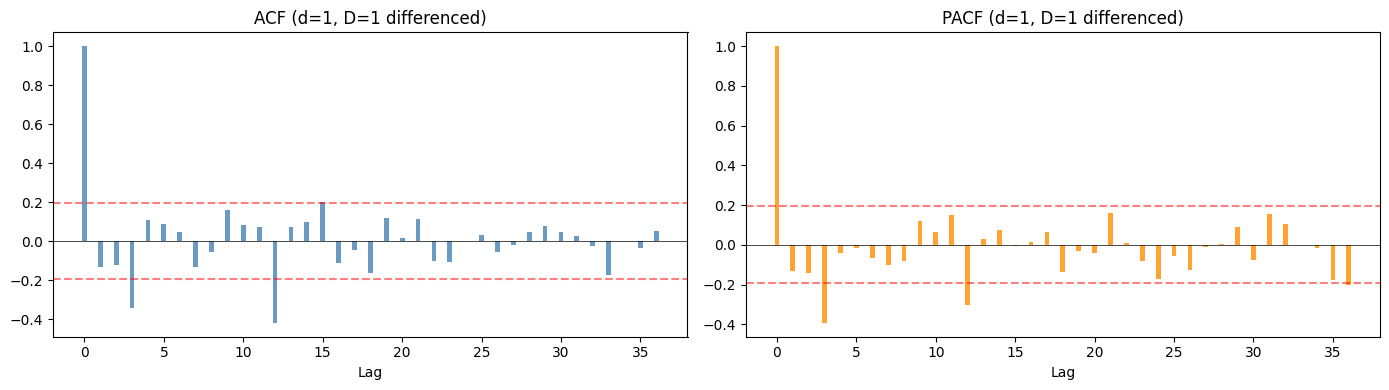

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot ACF
ax1.bar(range(37), acf_vals, width=0.3, color="steelblue", alpha=0.8)
ax1.axhline(ci, color="red", linestyle="--", alpha=0.5)
ax1.axhline(-ci, color="red", linestyle="--", alpha=0.5)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_title("ACF (d=1, D=1 differenced)")
ax1.set_xlabel("Lag")

# Plot PACF
ax2.bar(range(37), pacf_vals, width=0.3, color="darkorange", alpha=0.8)
ax2.axhline(ci, color="red", linestyle="--", alpha=0.5)
ax2.axhline(-ci, color="red", linestyle="--", alpha=0.5)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_title("PACF (d=1, D=1 differenced)")
ax2.set_xlabel("Lag")

plt.tight_layout()
plt.show()

In [12]:
# Print significant lags to document parameter reasoning
print(f"Significant ACF lags:")
for lag in range(1, 37):
    if abs(acf_vals[lag]) > ci:
        print(f"  Lag {lag:2d}: {acf_vals[lag]:+.3f}")

print(f"\nSignificant PACF lags:")
for lag in range(1, 37):
    if abs(pacf_vals[lag]) > ci:
        print(f"  Lag {lag:2d}: {pacf_vals[lag]:+.3f}")

Significant ACF lags:
  Lag  3: -0.341
  Lag 12: -0.418
  Lag 15: +0.203

Significant PACF lags:
  Lag  3: -0.393
  Lag 12: -0.305
  Lag 36: -0.202


## Make Model Fitting Helpers

In [13]:
def fit_sarima(train_series, order, seasonal_order, exog = None):
    """
    Fit a SARIMA (or SARIMAX with exog) model.

    Parameters:
        train_series: pd.Series of training data
        order: tuple (p, d, q) non-seasonal order
        seasonal_order: tuple (P, D, Q, s) seasonal order
        exog: optional exogenous variable array for SARIMAX
    """

    model = SARIMAX(
        train_series,
        order = order,
        seasonal_order = seasonal_order,
        exog = exog,

        # Let optimizer explore freely
        enforce_stationarity = False,
        enforce_invertibility = False
    )

    return model.fit(disp = False, maxiter = 500)

In [14]:
def forecast_and_evaluate(fitted, steps, actual, exog = None):
    """
    Generate forecasts and compute error metrics.

    Returns: predictions array, metrics dict, confidence interval DataFrame
    """
    # Generate forecast object
    # Extract predicted mean values as numpy array
    # Compute residuals
    fc = fitted.get_forecast(steps=steps, exog=exog)
    preds = fc.predicted_mean.values
    errors = actual - preds

    # Evaluation metrics
    metrics = {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "MAPE": np.mean(np.abs(errors / actual)) * 100
    }

    return preds, metrics, fc.conf_int()

In [15]:
def create_covid_indicator(index):
    """
    Create binary indicator for 1 during COVID period, 0 otherwise.

    March 2020 - December 2021 marked as affected based on
    the visible dip in the monthly crime series.
    """

    dates = pd.to_datetime(index)

    # Define COVID impact window based on observed structural break
    covid_start = pd.Timestamp("2020-03-01")
    covid_end = pd.Timestamp("2021-12-31")

    return ((dates >= covid_start) & (dates <= covid_end)).astype(int)

## AIC Grid Search and Model Selection

In [16]:
# grid search over parameter combinations
results = []

# Iterate over combinations of non-seasonal (p, q) and seasonal (P, Q) orders
for p, q, P, Q in product(range(0, 3), range(0, 3), range(0, 2), range(0, 2)):
    try:
        # Fit SARIMA model with seasonal period = 12
        # Store model configuration and information criteria
        fitted = fit_sarima(train["crime_count"], (p, 1, q), (P, 1, Q, 12))
        results.append({
            "order": f"({p},1,{q})({P},1,{Q},12)",
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": fitted.aic, "bic": fitted.bic,
        })
    # skip models that fail to converge
    except Exception:
        pass

# Convert results in df
grid_df = pd.DataFrame(results).sort_values("aic").reset_index(drop = True)

In [17]:
# Display results and choose best model parameters
print("Top 10 models by AIC:")
print(grid_df[["order", "aic", "bic"]].head(10).to_string(index = False))

# extract best parameters for use in subsequent cells
best = grid_df.iloc[0]
best_order = (int(best["p"]), 1, int(best["q"]))
best_seasonal = (int(best["P"]), 1, int(best["Q"]), 12)
print(f"\nBest: SARIMA{best['order']} (AIC={best['aic']:.1f})")

Top 10 models by AIC:
            order         aic         bic
(1,1,2)(0,1,1,12) 1299.252906 1311.582446
(0,1,2)(0,1,1,12) 1299.422113 1309.285746
(2,1,2)(0,1,1,12) 1300.848438 1315.643887
(1,1,2)(1,1,1,12) 1301.140540 1315.935988
(0,1,2)(1,1,1,12) 1301.387521 1313.717061
(2,1,2)(1,1,1,12) 1302.650838 1319.912195
(1,1,1)(0,1,1,12) 1311.564911 1321.474258
(2,1,1)(0,1,1,12) 1313.388031 1325.774715
(1,1,1)(1,1,1,12) 1313.412059 1325.798743
(0,1,1)(0,1,1,12) 1313.827405 1321.259415

Best: SARIMA(1,1,2)(0,1,1,12) (AIC=1299.3)


## SARIMAX with COVID Exogenous Variable
COVID-19 caused a sharp crime drop in April 2020 of around 4,400 normally its around 7,000. A binary indicator for the pandemic period (March 2020 - December 2021) lets the model account for this structural break rather than absorbing it into ARIMA residuals.

In [18]:
# Create COVID indicators for train and test periods
covid_train = create_covid_indicator(train.index)
covid_test = create_covid_indicator(test.index)   # all zeros (test is post-COVID)

# Fit SARIMAX using best parameters from grid search
sarimax_fit = fit_sarima(
    train["crime_count"], best_order, best_seasonal, exog=covid_train
)

In [19]:
# print model summary
print(f"SARIMAX{best['order']} + COVID")
print(f"  AIC: {sarimax_fit.aic:.1f}  BIC: {sarimax_fit.bic:.1f}")
print(f"  Coefficients:")

for name, val, pval in zip(sarimax_fit.params.index, sarimax_fit.params.values, sarimax_fit.pvalues.values):
    sig = "*" if pval < 0.05 else " "  # flag significant coefficients
    print(f"    {name:<12s} {val:+.6f}  (p={pval:.4f}) {sig}")

SARIMAX(1,1,2)(0,1,1,12) + COVID
  AIC: 1293.9  BIC: 1308.6
  Coefficients:
    x1           -719.372400  (p=0.0005) *
    ar.L1        +0.516858  (p=0.1574)  
    ma.L1        -0.793021  (p=0.0379) *
    ma.L2        -0.013528  (p=0.9497)  
    ma.S.L12     -0.948921  (p=0.1604)  
    sigma2       +125122.176916  (p=0.0880)  


In [20]:
# evaluate on holdout test set
sarimax_preds, sarimax_metrics, sarimax_ci = forecast_and_evaluate(
    sarimax_fit, n_test, test["crime_count"].values, exog=covid_test
)

print(f"Test: MAE={sarimax_metrics['MAE']:.0f}  RMSE={sarimax_metrics['RMSE']:.0f}  MAPE={sarimax_metrics['MAPE']:.1f}%")

Test: MAE=254  RMSE=303  MAPE=3.7%


### Model Interpretation

The selected **SARIMA(1,1,2)(0,1,1,12)** with a COVID indicator means:
- **AR(1):** each month's forecast uses the previous month's value as a predictor (captures short-term momentum)
- **d=1:** first-differencing removes the downward trend in crime counts
- **MA(2):** two lagged forecast-error terms smooth out short-term noise
- **D=1, s=12:** seasonal differencing removes the repeating yearly cycle (summer peaks, winter troughs)
- **Seasonal MA(1):** one seasonal error term at lag 12 fine-tunes how the model learns from last year's forecast mistakes
- **COVID coefficient (~-708, p<0.001):** during March 2020–December 2021, crime was about 708 fewer incidents per month than the seasonal pattern would predict. This prevents the pandemic dip from distorting the model's learned dynamics.

## Rolling-Origin Forecast Evaluation
Instead of a single 12-month-ahead forecast, evaluate with an expanding training window: fit on all data up to month t, predict month t+1, then expand and repeat. This produces 12 independent one-step-ahead forecasts and gives a more robust estimate of true forecast accuracy.

In [21]:
# Initiate parameters for predict and actual
rolling_preds = []
rolling_actuals = []

for i in range(n_test):
    # Define training window: expands as we move forward in time
    train_end = len(monthly) - n_test + i
    train_window = monthly.iloc[:train_end]

    # True observed value at current forecast step
    actual_val = monthly.iloc[train_end]["crime_count"]

    # Build COVID indicator for this training window and forecast step
    covid_window = create_covid_indicator(train_window.index)
    covid_step = create_covid_indicator(monthly.index[train_end:train_end+1])

    # Fit SARIMAX on expanding window, forecast 1 step ahead
    fit_i = fit_sarima(
        train_window["crime_count"], best_order, best_seasonal, exog = covid_window
    )

    # Generate 1-step ahead forecast using updated model
    fc_i = fit_i.get_forecast(steps = 1, exog = covid_step)

    # Store predicted value and actual value
    rolling_preds.append(fc_i.predicted_mean.values[0])
    rolling_actuals.append(actual_val)

# Convert results to numpy arrays for evaluation
rolling_preds = np.array(rolling_preds)
rolling_actuals = np.array(rolling_actuals)

In [22]:
# compute rolling-origin metrics
rolling_errors = rolling_actuals - rolling_preds
rolling_mae = np.mean(np.abs(rolling_errors))
rolling_rmse = np.sqrt(np.mean(rolling_errors ** 2))
rolling_mape = np.mean(np.abs(rolling_errors / rolling_actuals)) * 100

print(f"Rolling-origin one-step-ahead evaluation ({n_test} forecasts):")
print(f"  MAE:  {rolling_mae:.0f}")
print(f"  RMSE: {rolling_rmse:.0f}")
print(f"  MAPE: {rolling_mape:.1f}%")

Rolling-origin one-step-ahead evaluation (12 forecasts):
  MAE:  211
  RMSE: 258
  MAPE: 3.2%


## Naive Seasonal Baseline Comparison
Compare SARIMAX against a simple benchmark: "this month's forecast = same month last year." If SARIMAX can't beat this, it's not adding value.

In [23]:
# Naive seasonal baseline: forecast = same month from previous year
naive_preds = monthly.iloc[-n_test - 12 : -12]["crime_count"].values
naive_errors = test["crime_count"].values - naive_preds

# Evaluate baseline performance
naive_metrics = {
    "MAE": np.mean(np.abs(naive_errors)),
    "RMSE": np.sqrt(np.mean(naive_errors ** 2)),
    "MAPE": np.mean(np.abs(naive_errors / test["crime_count"].values)) * 100
}

In [24]:
# comparison table: naive vs SARIMAX (holdout) vs SARIMAX (rolling)
comp = pd.DataFrame([
    {"Model": "Naive seasonal (same month last year)",
     "MAE": naive_metrics["MAE"], "RMSE": naive_metrics["RMSE"], "MAPE": naive_metrics["MAPE"]},
    {"Model": f"SARIMAX{best['order']}+COVID (12-step holdout)",
     "MAE": sarimax_metrics["MAE"], "RMSE": sarimax_metrics["RMSE"], "MAPE": sarimax_metrics["MAPE"]},
    {"Model": f"SARIMAX{best['order']}+COVID (rolling 1-step)",
     "MAE": rolling_mae, "RMSE": rolling_rmse, "MAPE": rolling_mape},

]).sort_values("RMSE").reset_index(drop=True)

# Display results
print("Model Comparison:")
print(comp.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# Compute improvement over naive baseline
rmse_improvement = (1 - sarimax_metrics["RMSE"] / naive_metrics["RMSE"]) * 100
print(f"\nSARIMAX RMSE improvement over naive baseline: {rmse_improvement:.1f}%")

Model Comparison:
                                           Model   MAE  RMSE  MAPE
 SARIMAX(1,1,2)(0,1,1,12)+COVID (rolling 1-step) 211.0 257.8   3.2
SARIMAX(1,1,2)(0,1,1,12)+COVID (12-step holdout) 253.6 303.3   3.7
           Naive seasonal (same month last year) 319.6 494.2   4.8

SARIMAX RMSE improvement over naive baseline: 38.6%


## Residual Diagnostics
Verify that the model's residuals resemble white noise. No remaining patterns the model failed to capture.

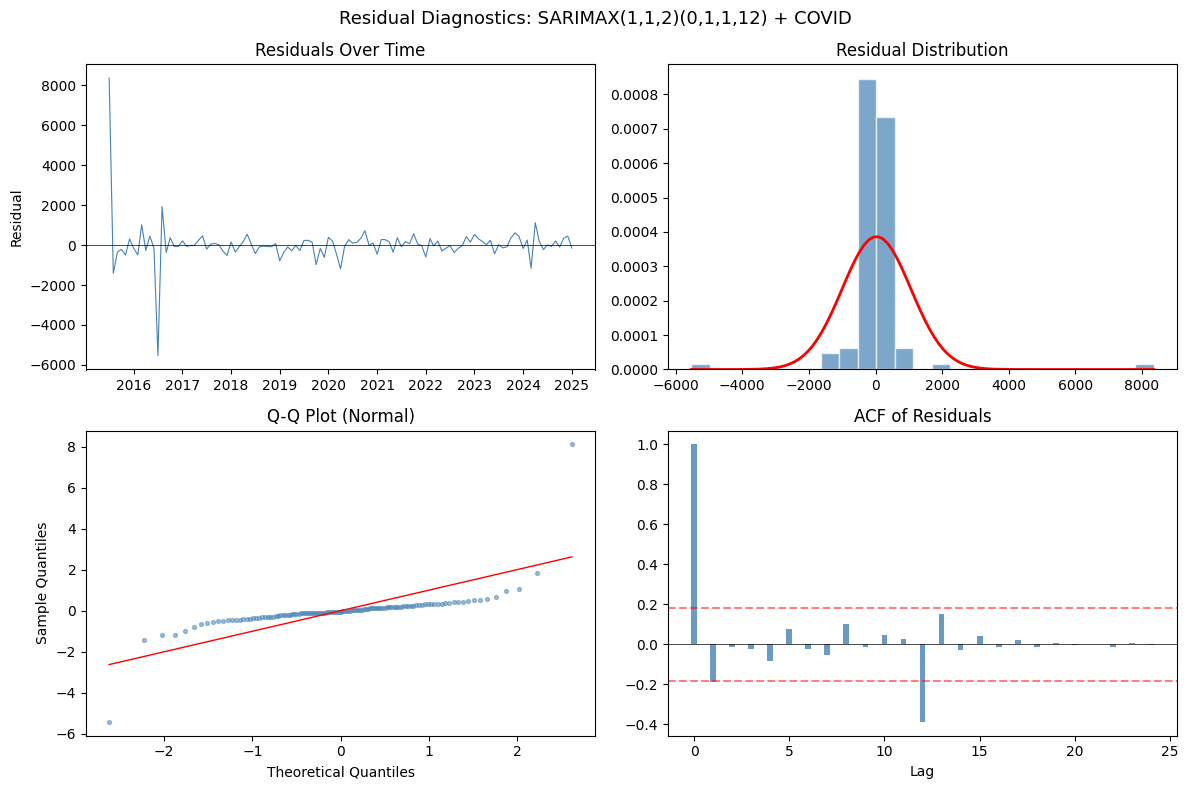

In [25]:
# Extract model residuals and remove any missing values
residuals = sarimax_fit.resid.dropna()
resid_arr = residuals.values
n_resid = len(resid_arr)

fig, axes = plt.subplots(2, 2, figsize = (12, 8))

# Residuals over time to look for patterns or variance changes
axes[0, 0].plot(residuals, color = "steelblue", linewidth = 0.8)
axes[0, 0].axhline(0, color = "black", linewidth = 0.5)
axes[0, 0].set_title("Residuals Over Time")
axes[0, 0].set_ylabel("Residual")

# histogram with normal overlay to check distribution shape
axes[0, 1].hist(residuals, bins = 25, density = True,
                 color = "steelblue", alpha=0.7, edgecolor = "white")

x = np.linspace(residuals.min(), residuals.max(), 100)

axes[0, 1].plot(x, sp_norm.pdf(x, residuals.mean(), residuals.std()),
                 color = "red", linewidth = 2)

axes[0, 1].set_title("Residual Distribution")

# Q-Q plot to check normality especially in the tails
sorted_resid = np.sort((resid_arr - resid_arr.mean()) / resid_arr.std())
theoretical = sp_norm.ppf(np.linspace(0.5/n_resid, 1 - 0.5/n_resid, n_resid))

axes[1, 0].scatter(theoretical, sorted_resid, s = 8, alpha = 0.5, color = "steelblue")

lim = max(abs(theoretical.min()), abs(theoretical.max()))

axes[1, 0].plot([-lim, lim], [-lim, lim], color = "red", linewidth = 1)

axes[1, 0].set_title("Q-Q Plot (Normal)")
axes[1, 0].set_xlabel("Theoretical Quantiles")
axes[1, 0].set_ylabel("Sample Quantiles")

# ACF of residuals to check for remaining autocorrelation
acf_resid = acf(resid_arr, nlags = 24)
ci_resid = 1.96 / np.sqrt(n_resid)

axes[1, 1].bar(range(25), acf_resid, width = 0.3, color = "steelblue", alpha = 0.8)

axes[1, 1].axhline(ci_resid, color = "red", linestyle="--", alpha = 0.5)
axes[1, 1].axhline(-ci_resid, color = "red", linestyle="--", alpha = 0.5)
axes[1, 1].axhline(0, color = "black", linewidth = 0.5)

axes[1, 1].set_title("ACF of Residuals")
axes[1, 1].set_xlabel("Lag")

# Overall title for the dashboard
fig.suptitle(f"Residual Diagnostics: SARIMAX{best['order']} + COVID", fontsize = 13)
plt.tight_layout()
plt.show()

In [26]:
# Ljung-Box test for autocorrelation in residuals
lb = acorr_ljungbox(residuals, lags = [12, 24], return_df = True)
print(f"Ljung-Box test:")
print(lb.to_string())

# Display residual stats results
print(f"\nResidual statistics:")
print(f"  Mean: {residuals.mean():.1f}")
print(f"  Std:  {residuals.std():.1f}")
print(f"  Skew: {residuals.skew():.3f}")
print(f"  Kurt: {residuals.kurt():.3f}")

Ljung-Box test:
      lb_stat  lb_pvalue
12  27.459406   0.006632
24  30.945204   0.155369

Residual statistics:
  Mean: 28.2
  Std:  1032.2
  Skew: 3.295
  Kurt: 44.116


**Residual finding:** The Ljung–Box test at lag 12 (p < 0.05) shows ther are some remaining seasonal autocorrelation. The finding indicates that the model does not fully capture all seasonal patterns. The kurtosis remain high of around 45, and Q–Q plot show heavy tails. This might be caused by a few extreme values during early years (2015–2016) and around COVID. The residuals are centered around zero, and show there is no clear trend. Most autocorrelations are within the confidence bounds. This means the model captures most of the time-series structure. The forecasting performance is still strong with MAPE ≈ 3.7%, but the normality assumption is only partly met and should be noted as a limitation.

## Forecast Results

In [27]:
# month-by-month forecast detail
print(f"12-Month Forecast (SARIMAX+COVID):")
print(f"{'Month':<10} {'Actual':>8} {'Forecast':>10} {'Error':>8} {'%Err':>7}")

for i in range(n_test):
    month_str = test.index[i].strftime("%Y-%m")
    actual_i = test["crime_count"].iloc[i]
    err = actual_i - sarimax_preds[i]
    pct = abs(err / actual_i) * 100

    print(f"{month_str:<10} {actual_i:>8.0f} {sarimax_preds[i]:>10.0f} {err:>+8.0f} {pct:>6.1f}%")

12-Month Forecast (SARIMAX+COVID):
Month        Actual   Forecast    Error    %Err
2025-02        5613       5681      -68    1.2%
2025-03        6703       6263     +440    6.6%
2025-04        6416       6189     +227    3.5%
2025-05        7129       6867     +262    3.7%
2025-06        6709       6872     -163    2.4%
2025-07        7126       7066      +60    0.8%
2025-08        7322       7208     +114    1.6%
2025-09        7339       6965     +374    5.1%
2025-10        7381       6861     +520    7.0%
2025-11        6624       6263     +361    5.4%
2025-12        6163       6168       -5    0.1%
2026-01        6378       5929     +449    7.0%


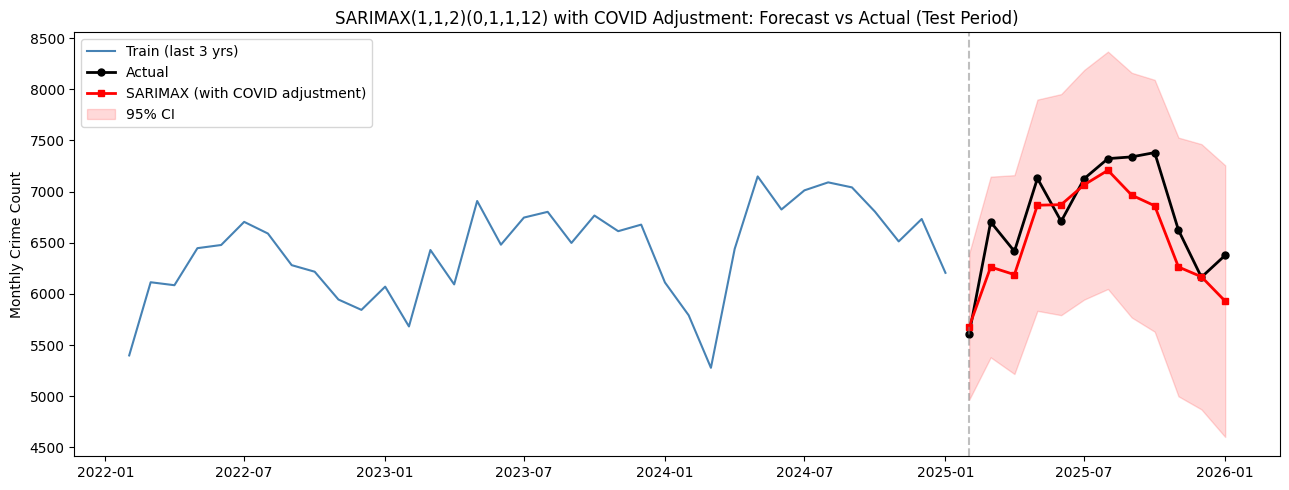

In [28]:
# Forecast plot with confidence intervals
# Show last 3 years of training for context
context = 36

fig, ax = plt.subplots(figsize=(13, 5))

# Plot recent training data so the forecast can be compared to past pattern
ax.plot(train.index[-context:], train["crime_count"].iloc[-context:],
        color = "steelblue", linewidth = 1.5, label = "Train (last 3 yrs)")

# Plot actual values in the test period
ax.plot(test.index, test["crime_count"],
        color = "black", linewidth = 2, marker = "o", markersize = 5, label = "Actual")

# Plot SARIMAX forecast for the test period
ax.plot(test.index, sarimax_preds,
        color = "red", linewidth = 2, marker = "s", markersize = 5, label = "SARIMAX (with COVID adjustment)")

# Plot 95% confidence interval
ax.fill_between(test.index,
                sarimax_ci.iloc[:, 0].values,
                sarimax_ci.iloc[:, 1].values,
                color = "red", alpha = 0.15, label = "95% CI")

# Mark where forecast period begins
ax.axvline(test.index[0], color="gray", linestyle="--", alpha=0.5)

# Add title, labels, and format
ax.set_title(f"SARIMAX{best['order']} with COVID Adjustment: Forecast vs Actual (Test Period)")
ax.set_ylabel("Monthly Crime Count")
ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()